In [2]:
import pandas as pd
import datetime as datetime
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('hourly_pm2.5_data.csv')

In [3]:
#merge the data and the time columns
df["date_time_merged"] = df["date_local"] + ' ' + df["time_local"]
#create a proper datetime column
df["date_time"] = pd.to_datetime(df["date_time_merged"])

In [4]:
df["years"] = df["date_time"].dt.year
df["days"] = df["date_time"].dt.day
df["hours"] = df['date_time'].dt.hour
df["months"] = df['date_time'].dt.month
df["day of week"] = df['date_time'].dt.day_of_week
df["day of year"] = df['date_time'].dt.day_of_year

#set a start date so we can track days elapsed
start_date = df["date_time"].iloc[0]

df["date_time_elapsed"] = (df['date_time'] - start_date)

df["days_elapsed"] = df['date_time_elapsed'].dt.days

In [5]:
df

,Unnamed: 0,state_code,county_code,site_number,parameter_code,poc,latitude,longitude,datum,parameter,...,date_time_merged,date_time,years,days,hours,months,day of week,day of year,date_time_elapsed,days_elapsed
0,0,49,35,3006,88101,1,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,1999-01-01 00:00,1999-01-01 00:00:00,1999,1,0,1,4,1,0 days 00:00:00,0
1,1,49,35,3006,88101,1,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,1999-01-02 00:00,1999-01-02 00:00:00,1999,2,0,1,5,2,1 days 00:00:00,1
2,2,49,35,3006,88101,1,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,1999-01-03 00:00,1999-01-03 00:00:00,1999,3,0,1,6,3,2 days 00:00:00,2
3,3,49,35,3006,88101,1,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,1999-01-04 00:00,1999-01-04 00:00:00,1999,4,0,1,0,4,3 days 00:00:00,3
4,4,49,35,3006,88101,1,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,1999-01-05 00:00,1999-01-05 00:00:00,1999,5,0,1,1,5,4 days 00:00:00,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220442,220442,49,35,3006,88101,2,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2026-07-31 19:00,2026-07-31 19:00:00,2026,31,19,7,4,212,10073 days 19:00:00,10073
220443,220443,49,35,3006,88101,2,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2026-07-31 20:00,2026-07-31 20:00:00,2026,31,20,7,4,212,10073 days 20:00:00,10073
220444,220444,49,35,3006,88101,2,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2026-07-31 21:00,2026-07-31 21:00:00,2026,31,21,7,4,212,10073 days 21:00:00,10073
220445,220445,49,35,3006,88101,2,40.736389,-111.872222,WGS84,PM2.5 - Local Conditions,...,2026-07-31 22:00,2026-07-31 22:00:00,2026,31,22,7,4,212,10073 days 22:00:00,10073


After adding a datetime column to our dataframe, we can now move onto grouping the measurements of PM 2.5 Concentration by Day. This will allow us to make keen extrapolations of the sample measurements by year, day of week, and by the season they are in.

In [6]:
# df_by_day = df.groupby(pd.Grouper(key="date_time", freq= "D"))['sample_measurement'].mean() #measurements grouped by day
# df_by_day.head()



In [7]:
# fig1, ax1 = plt.subplots(figsize=(10,4))
# df_by_day.plot(df_by_day['date_time'], df_by_day['sample_measurement'], ax=ax1,)
# ax1.set_title("Salt Lake City PM 2.5 Concentrations by Day from 1999 to 2026")
# ax1.set_xlabel("Years")
# ax1.set_ylabel("PM 2.5 Concentrations (µg/m³)")
# plt.show()
# plt.close()

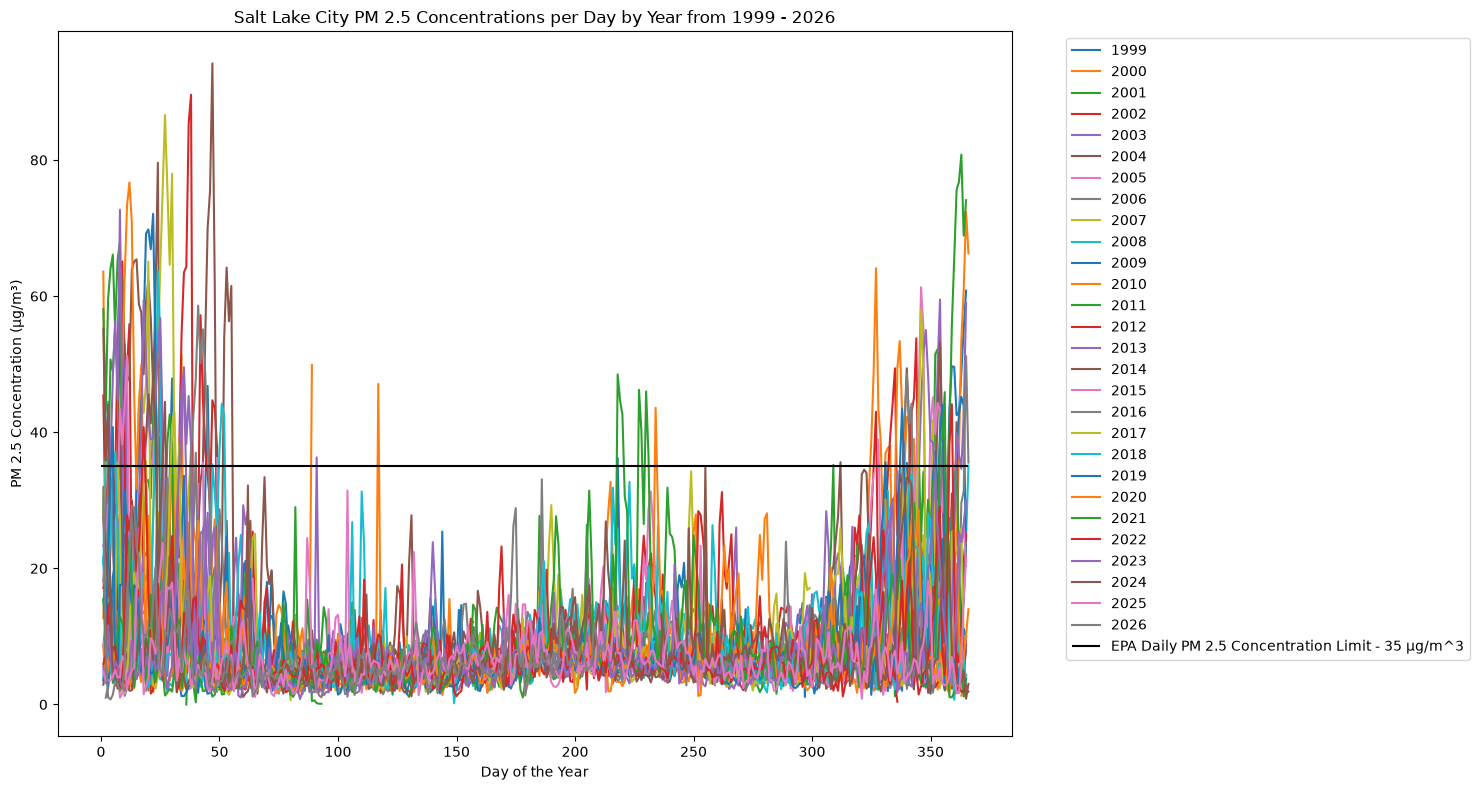

In [8]:
df_by_day = df.groupby(['years', 'day of year'])['sample_measurement'].mean()
df_by_day.head()

df_by_day_flatten = df_by_day.reset_index()
pivoted = df_by_day_flatten.pivot(index = 'day of year', columns = 'years', values='sample_measurement')
fig1, ax1 = plt.subplots(figsize=(15,8))
ax1.plot(pivoted, label = np.arange(1999,2027,1))
ax1.set_title("Salt Lake City PM 2.5 Concentrations per Day by Year from 1999 - 2026")
ax1.set_xlabel("Day of the Year")
ax1.set_ylabel("PM 2.5 Concentration (µg/m³)")
plt.hlines(
    y=35, xmin = 0, xmax = 366, colors = "black",  label = "EPA Daily PM 2.5 Concentration Limit - 35 µg/m^3"
)
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left')
plt.tight_layout()
plt.show()
# plt.close()

This graph plots daily PM 2.5 Concentrations against the Day of the Year that these concentrations were recorded in. Each line that is plotted represents a different year of data.

In [9]:
pivoted

years,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
day of year,,,,,,,,,,,,,,,,,,,,,
1,21.6,63.6,58.1,45.4,8.6,2.9,8.6,NaN,27.8,20.7,...,31.622917,21.088000,3.557143,8.425000,15.483673,5.934694,5.530612,27.551020,4.861224,31.955102
2,11.1,18.3,42.9,24.7,12.4,5.6,10.1,1.0,36.2,35.7,...,10.243750,16.628000,10.895918,3.537500,8.295918,7.385714,3.132653,22.506122,3.424490,7.108163
3,15.0,10.0,59.6,36.0,25.4,9.8,14.4,2.7,36.5,44.5,...,12.502083,20.100000,21.328571,5.073469,8.567347,14.634694,11.636735,17.227660,3.602041,1.032653
4,9.5,14.7,64.0,25.3,33.5,6.5,12.8,5.2,8.8,4.8,...,7.716667,25.400000,33.602041,8.044898,9.655102,6.336735,6.944898,13.971429,3.551020,0.728571
5,14.7,9.2,66.1,24.3,25.7,10.9,7.2,11.6,7.5,5.4,...,4.889796,34.056000,40.757143,8.777551,3.146939,8.204082,3.670833,4.883673,4.073469,1.438776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,43.0,37.2,76.8,5.3,11.2,17.9,4.9,2.7,7.8,8.7,...,23.479592,4.125000,2.768750,11.471429,2.093878,2.557143,25.397959,2.979592,1.677551,NaN
363,48.7,53.5,80.8,2.6,3.2,12.6,2.2,NaN,7.1,12.5,...,25.873469,7.346939,4.114583,3.840816,6.026531,1.848980,23.810204,3.346939,5.665306,NaN
364,55.2,60.9,68.9,4.5,5.9,4.5,5.1,15.0,2.1,15.0,...,9.397959,7.312245,11.081250,6.981633,1.138776,1.906122,26.612245,4.955102,15.381633,NaN


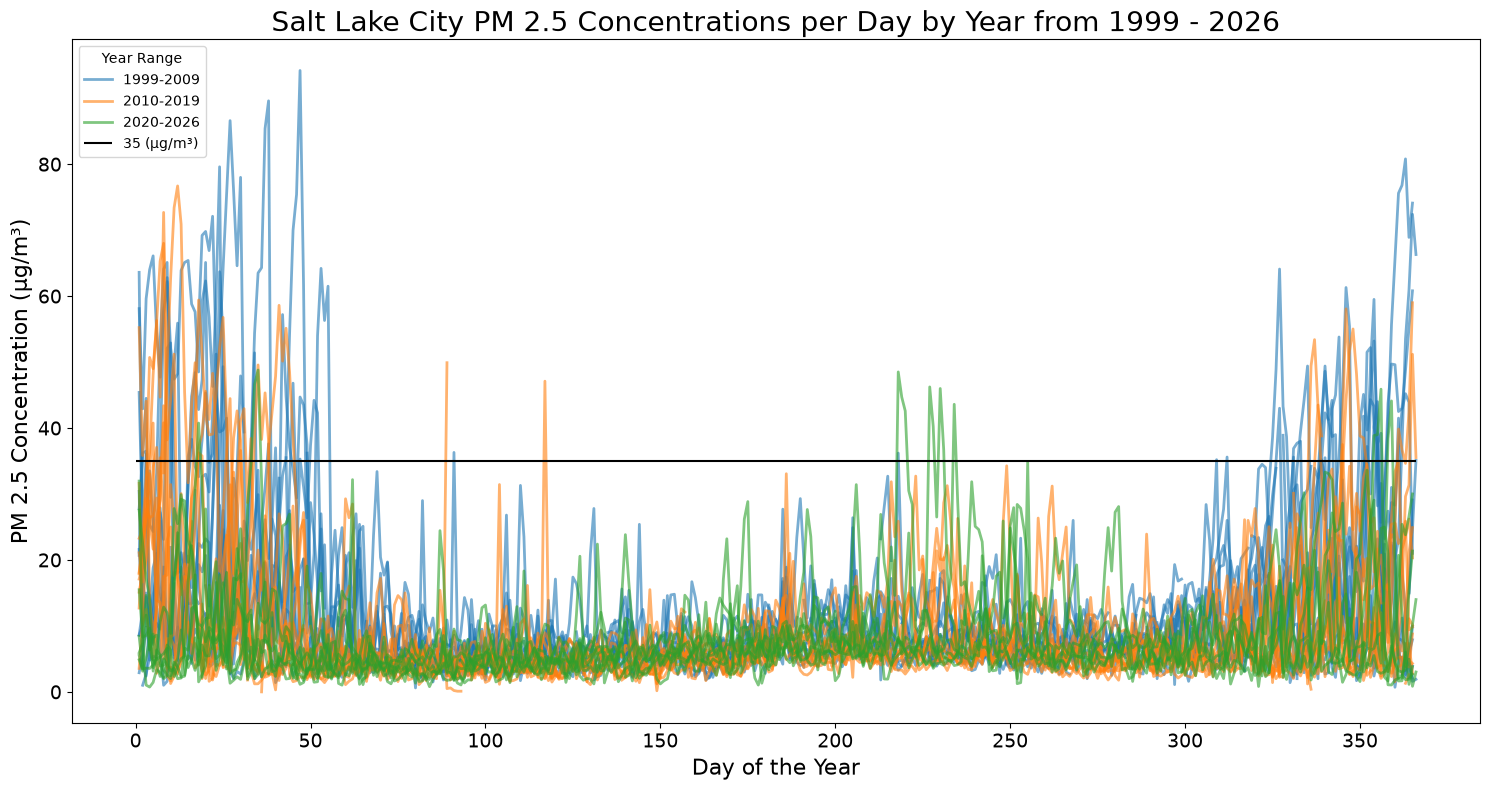

In [25]:
#we gotta make a plot that bins some of these lines together
bins = [1998, 2009, 2019, 2026]
labels = ['1999-2009', '2010-2019', '2020-2026']
color_map = {
    '1999-2009': '#1f77b4',  # Blue
    '2010-2019': '#ff7f0e',  # Orange
    '2020-2026': '#2ca02c'   # Green
}

def year_bins(year):
    year = int(year)
    if 1999 <= year <= 2009:
        return color_map['1999-2009'], '1999-2009'
    elif 2010 <= year <= 2019:
        return color_map['2010-2019'], '2010-2019'
    else:
        return color_map['2020-2026'], '2020-2026'

fig2, ax2 = plt.subplots(figsize=(15,8))

legend_labels = set()

for year in range(1999, 2027):
    col = year if year in pivoted.columns else str(year)
    if col not in pivoted.columns:
        continue
    
    colors, bin_label = year_bins(year)

    if bin_label not in legend_labels:
        label = bin_label
        legend_labels.add(bin_label)
    else:
        label = None

    ax2.plot(
        pivoted.index,
        pivoted[col],
        label = label, 
        color=colors,
        alpha = 0.6,
        linewidth=2,
    )

ax2.set_title("Salt Lake City PM 2.5 Concentrations per Day by Year from 1999 - 2026", fontsize = 20)
ax2.set_xlabel("Day of the Year", fontsize = 16)
ax2.set_ylabel("PM 2.5 Concentration (µg/m³)", fontsize = 16)
ax2.tick_params(axis='both', which='major', labelsize=14)
plt.hlines(
    y=35, xmin = 0, xmax = 366, colors = "black",  label = "35 (µg/m³)"
)
plt.legend(loc='upper left', title="Year Range")

plt.tight_layout()
plt.show()
# plt.close()

Try to bin around when different monitoring techniques used

Font size up to 14+++

TEOM 2013 - 2017 (2 diff POC #)

1999 - 2026 (Gravimetric Sampler)

BAM since 2015

Maybe bin around when standards were set

Text(0, 0.5, 'Days above 35 (µg/m³)')

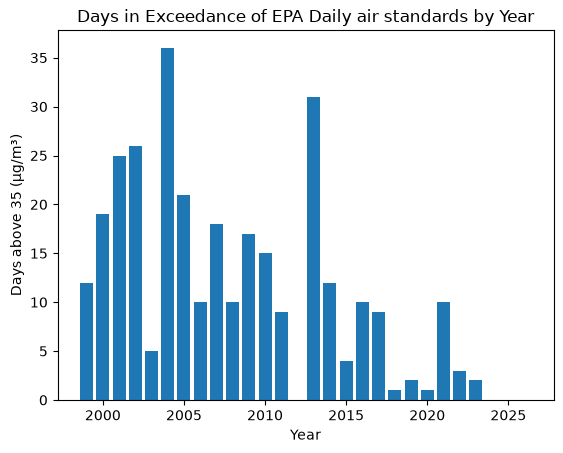

In [11]:
df_exceedance = df_by_day_flatten.groupby("years")["sample_measurement"].agg(lambda x: (x>35).sum())
df_exceedance
df_exceedance= pd.DataFrame(df_exceedance)
plt.bar(df_exceedance.index, df_exceedance["sample_measurement"])
plt.title("Days in Exceedance of EPA Daily air standards by Year")
plt.xlabel("Year")
plt.ylabel("Days above 35 (µg/m³)")

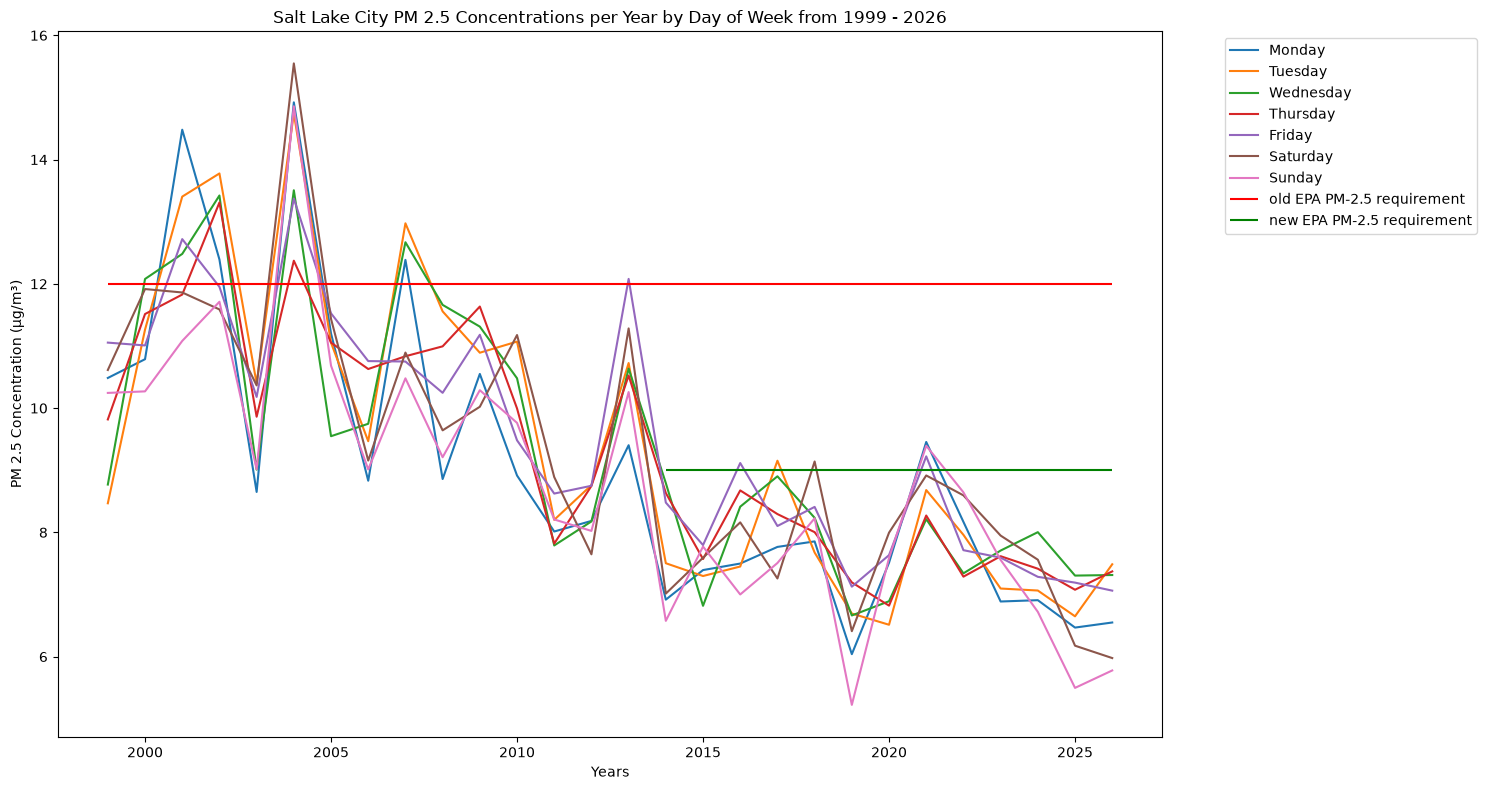

In [12]:
#now I will try to graph PM 2.5 concentrations by day of weak across all of our years. hourly will be tough to breach
df_by_dow = df.groupby(['years', 'day of week'])['sample_measurement'].mean()
df_by_dow.head()

df_by_dow_flat = df_by_dow.reset_index()
df_dow_pivoted = df_by_dow_flat.pivot(index = 'years', columns='day of week', values='sample_measurement')

fig3, ax3 = plt.subplots(figsize=(15,8))
ax3.plot(df_dow_pivoted, label = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
ax3.set_title("Salt Lake City PM 2.5 Concentrations per Year by Day of Week from 1999 - 2026")
ax3.set_xlabel("Years")
ax3.set_ylabel("PM 2.5 Concentration (µg/m³)")
plt.hlines(
    y=12,xmin=1999, xmax=2026, colors="red", label= "old EPA PM-2.5 requirement"
)
plt.hlines(
    y=9, xmin=2014, xmax = 2026, colors = "green", label = "new EPA PM-2.5 requirement"
)
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left')
plt.tight_layout()
plt.show()
plt.close()

#kind of useless?? bar chart would be better

In [13]:
df_dow = df.groupby(['day of week'],)['sample_measurement'].mean()
df_dow

day of week
0    7.530833
1    7.692486
2    7.922311
3    7.866394
4    8.137811
5    7.878053
6    7.421055
Name: sample_measurement, dtype: float64

In [14]:
# df_dow = df.groupby('day of week')['sample_measurement'].mean()
# df_dow_flat = df_dow.reset_index()

# plt.bar(df_dow_flat["day of week"], df_dow_flat["sample_measurement"])



In [15]:

# plt.bar(df_dow.index, df_dow['sample_measurement'])



# plt.bar(df_exceedance.index, df_exceedance["sample_measurement"])
# plt.title("PM 2.5 Concentrations by Year")
# plt.xlabel("Year")
# plt.ylabel("PM 2.5 Concentration (µg/m³)")

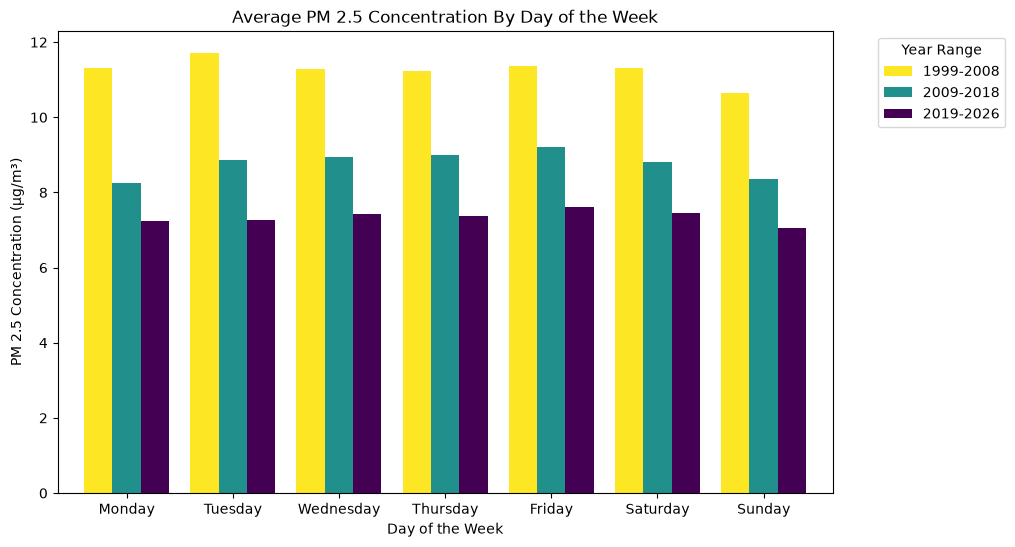

In [16]:
#creating multiple bar chart for plots of PM 2.5 Concentration by sets of years
#1999 - 2009, 2010 - 2019, 2019 - 2026?
df_dow_bar = df_dow_pivoted.reset_index()
bins = [1998, 2008, 2018, 2026]
year_labels = ["1999-2008", "2009-2018", "2019-2026"]
df_dow_bar["Year_Group"] = pd.cut(df_dow_bar["years"], bins=bins,labels=year_labels)
day_index = np.arange(0, 7)

#group the dataframe by the Year_Group column, this makes Year_Group the index and the columns are the days of the week
dow_grouped_years = df_dow_bar.groupby("Year_Group")[day_index].mean()

#transpose the group years plot so that we can have columns made by year group, and an index which is by day of week
dow_bar = dow_grouped_years.T
dow_bar.index = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

#time to set up the matplot!

fig4, ax4 = plt.subplots(figsize=(10,6))

#pandas plot function
dow_bar.plot(kind='bar', width = 0.8, colormap='viridis_r', ax=ax4)

#plot customization!
plt.title("Average PM 2.5 Concentration By Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("PM 2.5 Concentration (µg/m³)")
plt.xticks(rotation=0)
plt.legend(title= "Year Range", bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()